In [1]:
from AutoEncoder_Experiment import *
import sys, jax, json
import jax.numpy as jnp
from datetime import datetime

import jax_amber3 as ja
import training_functions as tf

jax.config.update("jax_enable_x64", True)

In [2]:
json_fn = 'Sigmoids_Dropout3.json'
with open(json_fn, 'r') as g:
        json_params = json.load(g)

In [3]:
#To be added to json
num_rmsd_epochs = 100 #Initial Run
nm_cutoff = 0.1 #target rmsd in nm
rmsd_cutoff = 1500 #num epochs to force training to summation
num_move_ave = 50 #number of previous points for moving average calculations
potential_threshold = 1e-3 #Target Potential NSD tolerance
cutoff_epoch = 30000 #maximum number of epochs of training

In [4]:
#Init Experiment
experiment = AutoEncoder_Experiment(json_fn)

(8000, 306) (2000, 306)
### MODEL TYPE = AE_Sigmoid_Dropout ###
Sigmoid_Dropout_AutoEncoder(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    n_latents = 7
    dropout_rates = [0.3, 0.3, 0.3]
)
INITIALIZATION COMPLETE


In [ ]:
experiment.train_nepochs(tf.structural_rng_step, 500, coefficients=[1,0])

epoch 0 atom_rmsd_nm 1.2785E+00 1.2784E+00 torsional 9.8912E-01 9.8926E-01 dPotEnr 3.8114E+15 3.8280E+15 Summation 2.2861E+01 2.2861E+01 B=1.0000E+00 L=0.0000E+00
epoch 1 atom_rmsd_nm 1.2686E+00 1.2685E+00 torsional 9.8537E-01 9.8552E-01 dPotEnr 6.4609E+14 6.4840E+14 Summation 2.2717E+01 2.2718E+01 B=1.0000E+00 L=0.0000E+00
epoch 2 atom_rmsd_nm 1.2590E+00 1.2590E+00 torsional 9.7368E-01 9.7385E-01 dPotEnr 2.6153E+13 2.6262E+13 Summation 2.2509E+01 2.2510E+01 B=1.0000E+00 L=0.0000E+00
epoch 3 atom_rmsd_nm 1.2502E+00 1.2502E+00 torsional 9.5646E-01 9.5655E-01 dPotEnr 3.6182E+10 3.6391E+10 Summation 2.2262E+01 2.2262E+01 B=1.0000E+00 L=0.0000E+00
epoch 4 atom_rmsd_nm 1.2415E+00 1.2414E+00 torsional 9.4219E-01 9.4227E-01 dPotEnr 1.2238E+10 1.2307E+10 Summation 2.2041E+01 2.2042E+01 B=1.0000E+00 L=0.0000E+00
epoch 5 atom_rmsd_nm 1.2327E+00 1.2327E+00 torsional 9.3918E-01 9.3927E-01 dPotEnr 8.3017E+09 8.3468E+09 Summation 2.1917E+01 2.1917E+01 B=1.0000E+00 L=0.0000E+00
epoch 6 atom_rmsd_nm 1

In [7]:
experiment.train_scaling_coef(tf.structural_rng_step, 100, 0)

epoch 25 atom_rmsd_nm NAN NAN torsional NAN NAN dPotEnr NAN NAN Summation NAN NAN B=0.0000E+00 L=0.0000E+00
epoch 26 atom_rmsd_nm NAN NAN torsional NAN NAN dPotEnr NAN NAN Summation NAN NAN B=0.0000E+00 L=0.0000E+00
epoch 27 atom_rmsd_nm NAN NAN torsional NAN NAN dPotEnr NAN NAN Summation NAN NAN B=0.0000E+00 L=0.0000E+00


KeyboardInterrupt: 

In [ ]:
experiment.train_scaling_torsional(400, freq=5)

In [ ]:
end_scaling_epoch = experiment.train_scaling_potential(cutoff_epoch, freq=5)
#freq=number of epochs before reevaluate pot rmsd ratio,  this should be low as the dataset is large (many batches per epoch)
print('END SCALING POTENTIAL')
walltime = datetime.now() - start
print(f'Walltime per epoch was {walltime}')
experiment.save_loss_data()
experiment.write_model_to_ckpt()

In [ ]:
experiment.train_summation(1e-1, 10, cutoff_epoch)
print('END TRAINING')
walltime = datetime.now() - start
print(f'Walltime was {walltime}')
#experiment.save_loss_data()
#experiment.write_model_to_ckpt()

In [ ]:
rng_init = jax.random.PRNGKey(54)
rng, key = jax.random.split(rng_init)
recon, latents = experiment.state.apply_fn({'params':experiment.state.params}, experiment.test_data, rng)

In [ ]:
for i in range(latents.shape[-1]):
    plt.clf()
    plt.title(f'Latent {i}')
    _ = plt.hist(latents[:, i], bins=100)
    plt.show()

In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
ics = []
for i in range(1, 31):
    X = np.array(latents)
    MM = GaussianMixture(n_components=i).fit(X)
    ics.append((i, MM.aic(X), MM.bic(X)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1])
_ = plt.plot(ics[:, 0], ics[:, 2])
plt.legend(('Akaike Info Criterion', 'Bayes Info Criterion'))
plt.xlabel('Num Components')
plt.show()

In [ ]:
X = np.array(latents)
MM = GaussianMixture(n_components=1).fit(X) #chosen based on above graph
samples = MM.sample(1800)[0]

In [ ]:
for i in range(samples.shape[-1]):
    plt.clf()
    _ = plt.hist(latents[:,i], bins=100, histtype='step', color='g')
    _ = plt.hist(samples[:,i], bins=100, histtype='step', color='b')
    plt.legend(('Reconstructed from Input', 'Sampled from Mixture Model'))
    plt.title(f'Latent {i+1}')
    plt.show()

In [ ]:
n_L = latents.shape[-1]
fig, axs = plt.subplots(n_L, n_L, figsize=(15, 10), sharex='col', sharey='row')
for i in range(n_L):
    for j in range(n_L):
        axs[i,j].scatter(latents[:,j], latents[:,i])
fig.savefig('7L.png', dpi=600)

In [ ]:
from jax_amber2 import *
gas_fun = get_amber_gas_energy_function('Simulation/1crn_H.prmtop')

In [ ]:
plt.clf()

recon_energies = gas_fun(recon)

decoded_samples = experiment.model.apply({'params': experiment.state.params}, samples, rng, method=experiment.model.decode)
sampled_energies = gas_fun(decoded_samples)

org_energies = gas_fun(experiment.test_data)

threshold = 1e3
num_excluded_gmm = len(sampled_energies) - len(sampled_energies[sampled_energies<threshold])
num_excluded_nn  = len(recon_energies) - len(recon_energies[recon_energies<threshold])
print(f'Excluding Outliers GMM - {num_excluded_gmm} RECON - {num_excluded_nn}')

_ = plt.hist(org_energies[org_energies < threshold], bins=100, histtype='step', color='r')
_ = plt.hist(recon_energies[recon_energies<threshold], bins=100, histtype='step', color='g')
_ = plt.hist(sampled_energies[sampled_energies<threshold], bins=100, histtype='step', color='b')

plt.legend(('Test Data Potential', 'Reconstructed from Test', 'Sampled from Mixture Model'))
plt.xlabel('Energy (kJ/mol)')
plt.title('Comparison of Energies - GMM and NN')
plt.show()

In [ ]:
plt.clf()
_ = plt.hist(org_energies, bins=100, histtype='step', color='r')
plt.show()
plt.clf()
_ = plt.hist(recon_energies, bins=100, histtype='step', color='g')
plt.show()
plt.clf()
_ = plt.hist(sampled_energies, bins=100, histtype='step', color='b')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [47]:
import math
def cosine_taylor_expansion(xs, num_terms):
    nth_term = lambda n, x: ((-1)**n)*((x)**(2*n))/(math.factorial(2*n))
    result = jnp.zeros(xs.shape)
    for i in range(0, num_terms):
        result += nth_term(i, xs)
    return result

def taylor_torsional_dist(xs):
    return jnp.sqrt(2*(1-cosine_taylor_expansion(xs, 10)))

In [52]:
xs = jnp.linspace(-0.0003 * jnp.pi, 0.0003*jnp.pi, 100)

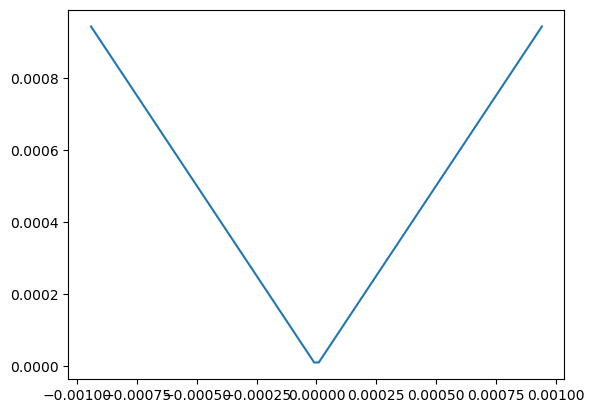

In [53]:
plt.clf()
ys_cos = jnp.cos(xs)
taylor_exp = taylor_torsional_dist(xs)
plt.plot(xs, taylor_exp)

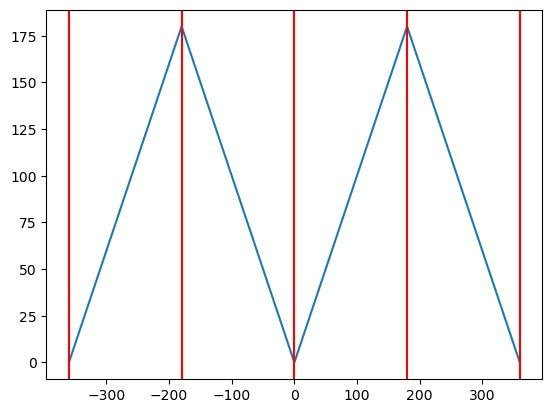

In [21]:
xs = jnp.linspace(-2 * 180, 2*180, 10000)
y_fun = lambda xs: 180 - jnp.abs(jnp.abs(xs) - 180)
ys = y_fun(xs)
import matplotlib.pyplot as plt
plt.clf()
_ = plt.plot(xs, ys)
for i in [-360, -180, 0, 180, 360]:
    plt.axvline(i, color='r')
plt.show()